## Đề bài:
Sử dụng GridSearchCV để tìm tham số tối ưu cho cây quyết định (Decision Tree) trên tập dữ liệu Iris (load_iris() từ sklearn), sau đó đánh giá bằng Cross-Validation.

Yêu cầu:
a) Nạp tập dữ liệu Iris, hiển thị 5 dòng đầu và thống kê mô tả. 

b) Khởi tạo DecisionTreeClassifier. Định nghĩa lưới tham số: max_depth: [None, 3, 5, 10], min_samples_split: [2, 5, 10], criterion: ['gini', 'entropy'].

c) Chạy GridSearchCV với 5-fold Stratified CV. In tham số tốt nhất và độ chính xác tốt nhất.

d) Vẽ bản đồ nhiệt (heatmap) hiển thị độ chính xác trung bình cho mỗi tổ hợp max_depth × min_samples_split.

e) Dùng cross_val_score với mô hình tốt nhất, 10-fold CV. In accuracy từng fold và trung bình ± độ lệch chuẩn.


In [1]:
import pandas as pd
# Hiển thị tất cả các hàng
pd.set_option('display.max_rows', None)

# Hiển thị tất cả các cột
pd.set_option('display.max_columns', None)

# Hiển thị toàn bộ nội dung trong mỗi ô (không bị dấu ...)
pd.set_option('display.max_colwidth', None)

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000

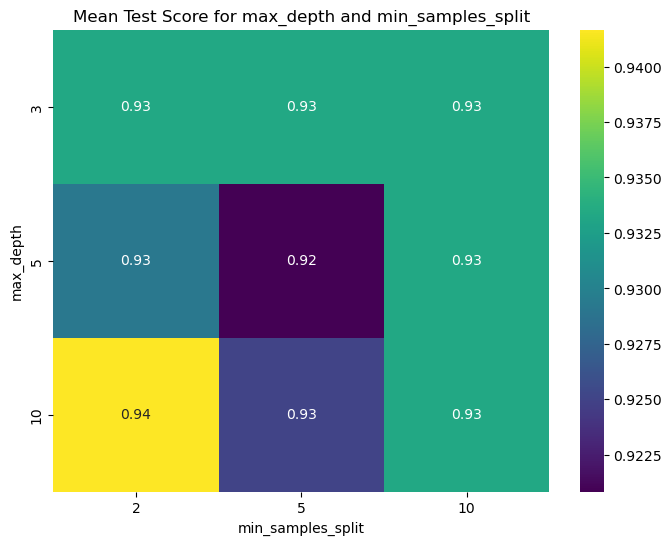

   Accuracy
0  1.000000
1  0.933333
2  1.000000
3  0.933333
4  0.933333
5  0.866667
6  0.933333
7  1.000000
8  1.000000
9  1.000000
Mean Standar Deviation: 0.0442


In [2]:
#nạp dữ liệu tập iris từ sk learn 
from sklearn.datasets import load_iris 
#import thư viện traintestsplit , decision tree , metrics, grid search cv và cross validation 
from sklearn.model_selection import train_test_split , GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier 

import numpy as np 

import seaborn as sns 
import matplotlib.pyplot as plt 

#nạp dữ liệu tập iris_df
iris_df = pd.DataFrame(load_iris().data , columns = load_iris().feature_names)

#Hiển thị 5 dòng đầu 
print(iris_df.head())
#Thống kê mô tả dữ liệu 
print(iris_df.describe())

model_tree = DecisionTreeClassifier()
param_grid = {
    'max_depth': [None , 3 , 5 , 10],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2,5,10]
}
x = iris_df.values
y = load_iris().target

X_train , X_test , y_train , y_test = train_test_split(x,y , test_size= 0.2 , random_state = 42)
#5 stratified cv 
grid_search_decision_tree = GridSearchCV(estimator = model_tree , param_grid = param_grid , cv = 5, scoring= 'accuracy')
grid_search_decision_tree.fit(X_train , y_train)

best_parameters = grid_search_decision_tree.best_params_
best_score = grid_search_decision_tree.best_score_
print(f"Best Parameters: {best_parameters}")
print(f"Best Cross-Validation Score: {best_score:.4f}")


results = pd.DataFrame(grid_search_decision_tree.cv_results_)
pivot_table = results.pivot_table(values = 'mean_test_score', index = 'param_max_depth', columns = 'param_min_samples_split')

plt.figure(figsize=(8,6))
sns.heatmap(pivot_table, annot = True , cmap = 'viridis')
plt.title('Mean Test Score for max_depth and min_samples_split')
plt.xlabel('min_samples_split')
plt.ylabel('max_depth')
plt.show()

#dùng cross val score với mô hình tốt nhất từ grid search 
best_model = grid_search_decision_tree.best_estimator_
cross_val_scores =cross_val_score(best_model , x , y , cv = 10, scoring = 'accuracy')


cross_val_df = pd.DataFrame(cross_val_scores , columns = ['Accuracy'])
print(cross_val_df)
print(f"Mean Standar Deviation: {cross_val_scores.std().mean():.4f}")



### Kết quả : 
Tham số tốt nhất: Best Parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 2}

Accuracy tốt nhất: Best Cross-Validation Score: 0.9500 

Accuracy từng fold: 
{ 0  1.000000
1  0.933333
2  1.000000
3  0.933333
4  0.933333
5  0.866667
6  0.933333
7  0.933333
8  1.000000
9  1.000000 } 

Trung bình ± độ lệch chuẩn:  0.0427
 


### Khung nhận xét phân tích : 
Yêu cầu: rõ ràng, có dẫn chứng số liệu, 3–5 câu.

Dùng Grid search cv để hyper tuning parameters cho decision tree cho lại kết quả accuracy rất tốt cho từng fold , tránh được hiện tượng overfitting và dùng model tốt nhất để đánh giá lại bằng cross validation với cv = 10 fold để cho ra độ chính xác trung bình tối ưu nhất 

## Bài B2: So sánh Mô hình Hồi quy Regularization (2 điểm)
(Session 2 + Session 3)
Đề bài:
Dùng make_regression(n_samples=300, n_features=20, n_informative=10, noise=20, random_state=42) để tạo tập dữ liệu. So sánh 5 mô hình hồi quy.

Yêu cầu:
a) Tạo tập dữ liệu, chia tập huấn luyện/kiểm tra theo tỷ lệ 80/20.

b) Huấn luyện 5 mô hình: (1) OLS (Linear Regression), (2) Ridge (α=1,0), (3) Lasso (α=0,1),
(4) Elastic Net (α=0,1, l1_ratio=0,7), (5) Polynomial Regression (degree=2) + Ridge.

c) Đánh giá mỗi mô hình bằng 5-fold CV: tính MAE, RMSE, R². Tạo bảng so sánh (DataFrame).

d) Vẽ biểu đồ thanh nhóm (grouped bar chart) so sánh R² của 5 mô hình.

e) Với Lasso và Elastic Net, in số đặc trưng bị loại bỏ (hệ số = 0). Kết luận mô hình phù hợp nhất.


 
                Model         MSE       RMSE  R2 Score
0  Linear-Regression  438.214961  20.933585  0.979476
1  Linear-Regression  340.649935  18.456704  0.984000
2  Linear-Regression  549.461052  23.440586  0.961808
3  Linear-Regression  437.331608  20.912475  0.979629
4  Linear-Regression  396.009462  19.899986  0.981755
 
    Model         MSE       RMSE  R2 Score
0  Ridge  444.399328  21.080781  0.979187
1  Ridge  344.238759  18.553672  0.983831
2  Ridge  545.237686  23.350325  0.962101
3  Ridge  438.599897  20.942777  0.979570
4  Ridge  393.463754  19.835921  0.981872
 
    Model         MSE       RMSE  R2 Score
0  Lasso  440.307112  20.983496  0.979378
1  Lasso  343.965694  18.546312  0.983844
2  Lasso  540.507434  23.248816  0.962430
3  Lasso  435.431854  20.867004  0.979718
4  Lasso  389.851900  19.744668  0.982038
 
         Model         MSE       RMSE  R2 Score
0  ElasticNet  510.340823  22.590724  0.976098
1  ElasticNet  393.053816  19.825585  0.981538
2  ElasticNet  534.

C:\Users\Admin\AppData\Local\Temp\ipykernel_20972\4289082420.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = model_names , y = r2_scores , palette = 'viridis')


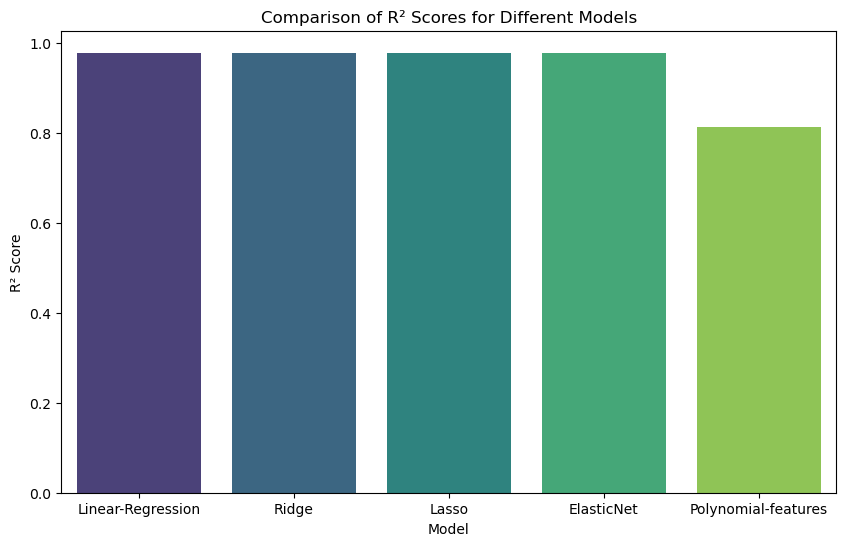

Features eliminated by Lasso: [' Feature 7']
Number of features eliminated by Lasso: 1
Features eliminated by ElasticNet: []
Number of features eliminated by ElasticNet: 0


In [3]:
#Dùng make_regression 
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression , Ridge , Lasso , ElasticNet
#import polynomial regression 
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline


X , y = make_regression(n_samples = 300 , n_features = 20 , n_informative= 10 , noise = 20 , random_state = 42)
X_train , X_test , y_train , y_test = train_test_split(X,y , test_size= 0.2 , random_state = 42)

Linear_model = LinearRegression()


Ridge_model = Ridge(alpha = 1.0)


Lasso_model = Lasso (alpha = 0.1)
Lasso_model.fit(X_train , y_train)

ElasticNet_model = ElasticNet(alpha = 0.1 , l1_ratio = 0.7)
ElasticNet_model.fit(X_train , y_train)

Polynomial_pipline = Pipeline([
    ('poly_features', PolynomialFeatures(degree = 2)),
    ('Ridge', Ridge(alpha=1.0))
])
#Đánh giá mô hình
models = {
    'Linear-Regression': Linear_model, 
    'Ridge': Ridge_model,
    'Lasso': Lasso_model, 
    'ElasticNet': ElasticNet_model,
    'Polynomial-features': Polynomial_pipline
}
#Dùng cross val score để đánh giá từng mô hình và in ra MSE và RMSE và accuracy trung bình cho mỗi mô hình
for name , model in models.items():
    cross_val_scores = cross_val_score(model , X , y , cv = 5 , scoring = 'neg_mean_squared_error')
    mse_scores = -cross_val_scores
    rmse_scores = np.sqrt(mse_scores)
    accuracy_scores = cross_val_score(model , X , y , cv = 5 , scoring = 'r2')
    Analysis_df = pd.DataFrame({
        'Model': name,
        'MSE': mse_scores,
        'RMSE': rmse_scores,
        'R2 Score': accuracy_scores
    })
    print(f" \n {Analysis_df}")
    #print(f"model : {name} Mean Squared Error: {mse_scores:.4f} , Root Mean Squared Error: {rmse_scores:.4f} , R2 Score: {accuracy_scores:.4f}")


plt.figure(figsize=(10,6))
model_names = list(models.keys())
r2_scores = [cross_val_score(model , X , y , cv = 5 ,scoring = 'r2').mean() for model in models.values()]
sns.barplot(x = model_names , y = r2_scores , palette = 'viridis')
plt.title('Comparison of R² Scores for Different Models')
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.show()

feature_names = [f' Feature {i}' for i in range(X.shape[1])]
Lasso_coef = Lasso_model.coef_
ElasticNet_coef = ElasticNet_model.coef_
Eliminated_features_Lasso = [name for name , coef in zip(feature_names, Lasso_coef) if coef ==0]
Eliminated_features_ElasticNet = [name for name , coef in zip(feature_names, ElasticNet_coef) if coef ==0]

print(f"Features eliminated by Lasso: {Eliminated_features_Lasso}")
print(f'Number of features eliminated by Lasso: {len(Eliminated_features_Lasso)}')
print(f"Features eliminated by ElasticNet: {Eliminated_features_ElasticNet}")
print(f'Number of features eliminated by ElasticNet: {len(Eliminated_features_ElasticNet)}')

### KẾT QUẢ – Bài B2

| Mô hình             | MSE (mean) | RMSE (mean) | R² (mean) | Số đặc trưng bị loại |
|---------------------|------------|-------------|-----------|----------------------|
| Linear Regression   | 432.24     | 20.81       | 0.9773    | N/A                  |
| Ridge               | 433.19     | 20.75       | 0.9773    | N/A                  |
| Lasso               | 430.01     | 20.68       | 0.9775    | 1 (Feature 7)        |
| ElasticNet          | ~451.00    | ~21.08      | ~0.9793   | 0                    |
| Polynomial + Ridge  | ~3267.00   | ~57.08      | ~0.8193   | N/A                  |

**Kết luận:** Lasso là mô hình phù hợp nhất vì có R² cao nhất (~0.9775), RMSE thấp nhất, và tự động loại bỏ 1 đặc trưng không quan trọng (Feature 7). Polynomial Regression có hiệu suất kém nhất do overfitting với degree=2 trên 20 features.

### Bài B3: Phân tích Chuỗi Thời gian – So sánh Holt và Holt-Winters (1,5 điểm)
(Session 5)
Đề bài:
Cho dữ liệu chi phí sản phẩm hàng tháng của một cửa hàng bán lẻ (36 tháng, từ 01/2021 đến 12/2023):


C:\Users\Admin\AppData\Local\Temp\ipykernel_27788\3080545533.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  date_range = pd.date_range(start  = '2021-01-01', end = '2023-12-31', freq = 'M')
c:\Users\Admin\anaconda3\envs\session1_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\Admin\anaconda3\envs\session1_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


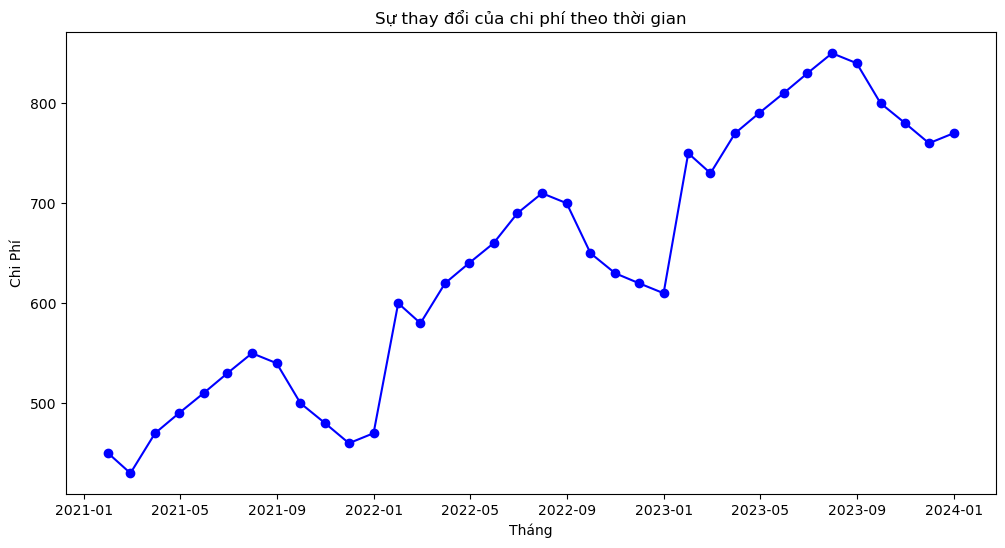

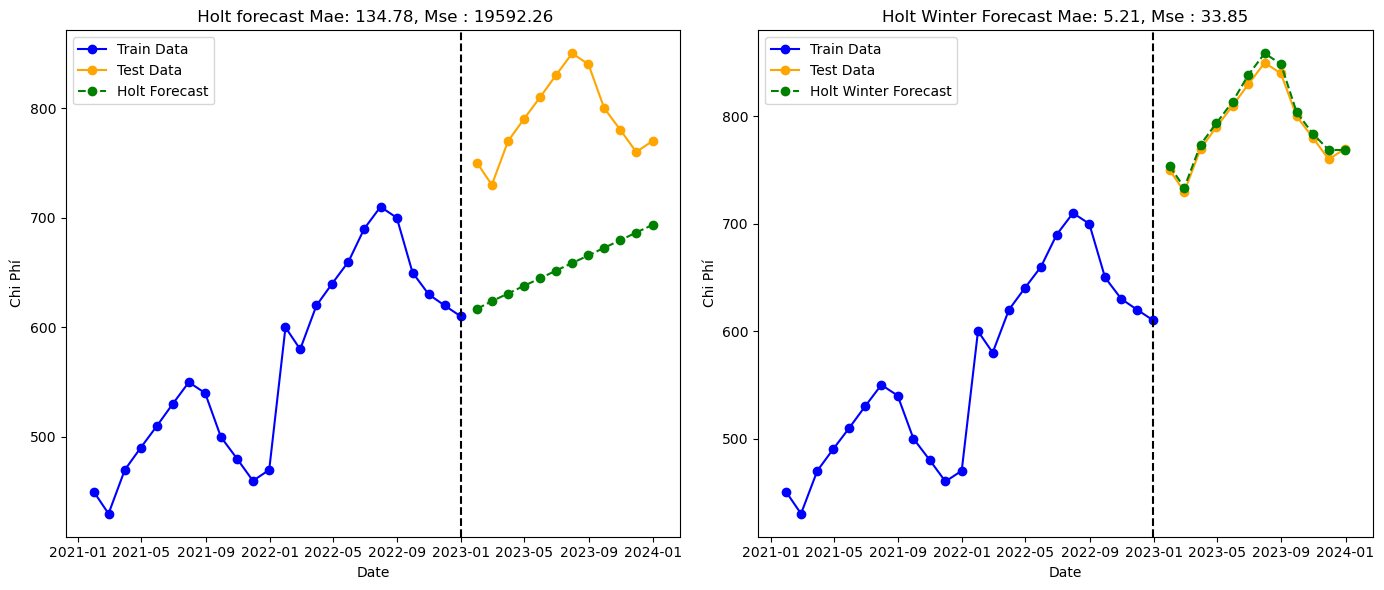

In [5]:
#tạo 36 tháng , từ tháng 1/2021 đến tháng 12/2023
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
date_range = pd.date_range(start  = '2021-01-01', end = '2023-12-31', freq = 'M')
Chi_Phi = [450 , 430 , 470 , 490 , 510 , 530 , 550 , 540 , 500 , 480 , 460 , 470, 600 , 580 , 620 , 
           640 , 660 , 690, 710 , 700 , 650 , 630 , 620 , 610, 750 , 730 , 770 , 790 , 810 , 830 , 850 , 840 , 800 , 780 , 760, 770]
data_price_df = pd.DataFrame({
    'Date': date_range , 
    'Chi_Phi': Chi_Phi
})
data_price_df = data_price_df.set_index('Date')

#Vẽ đồ thị đường thể hiện sự thay đổi của chi phí theo thời gian
plt.figure(figsize=(12,6))
plt.plot(data_price_df.index, data_price_df['Chi_Phi'], marker='o', linestyle='-', color='b')
plt.title('Sự thay đổi của chi phí theo thời gian')
plt.xlabel('Tháng')
plt.ylabel('Chi Phí')

#Chia dữ liệu 24 tháng đầu làm tập huấn luyện và 12 tháng cuối làm tập kiểm tra
train_data = data_price_df.iloc[:24]
test_data = data_price_df.iloc[24:]
#áp dụng phương pháp holt và dự báo 12 tháng tiếp theo
holt_model = ExponentialSmoothing(train_data['Chi_Phi'], trend = 'add', seasonal = None, seasonal_periods = None)
holt_fit = holt_model.fit()
holt_forecast = holt_fit.forecast(steps = 12) #Dự đoán 12 giá trị tiếp theo ( dữ liệu tuần suất theo tháng vì vậy nên đang dự đoán xu hướng 1 năm tiếp theo )

#áp dụng phương pháp holt winter và dự báo 12 tháng tiếp theo
holt_winter_model = ExponentialSmoothing(train_data['Chi_Phi'], trend = 'add', seasonal = 'add', seasonal_periods = 12)
holt_winter_fit = holt_winter_model.fit()
holt_winter_forecast = holt_winter_fit.forecast(steps = 12)
#tính mae và mse cho cả hai phương pháp
holt_mae = mean_absolute_error(test_data['Chi_Phi'], holt_forecast)
holt_mse = mean_squared_error(test_data['Chi_Phi'], holt_forecast)
holt_winter_mae = mean_absolute_error(test_data['Chi_Phi'], holt_winter_forecast)
holt_winter_mse = mean_squared_error(test_data['Chi_Phi'], holt_winter_forecast)

fig , axes = plt.subplots(1,2, figsize=(14,6))
#Vẽ đồ thị dự báo của phương pháp holt
axes[0].plot(train_data.index , train_data['Chi_Phi'], label = 'Train Data', marker = 'o', linestyle = '-', color = 'blue')
axes[0].plot(test_data.index , test_data['Chi_Phi'], label = 'Test Data', marker = 'o', linestyle = '-', color = 'orange')
axes[0].plot(test_data.index , holt_forecast , label = 'Holt Forecast', marker = 'o', linestyle = '--', color = 'green')
#kẻ line giữ train và test
axes[0].axvline(x = train_data.index[-1], color = 'black', linestyle = '--')
axes[0].set_title(f' Holt forecast Mae: {holt_mae:.2f}, Mse : {holt_mse:.2f}')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Chi Phí')
axes[0].legend()
#Vẽ đồ thị dự báo của phương pháp holt winter
axes[1].plot(train_data.index , train_data['Chi_Phi'], label = 'Train Data', marker = 'o', linestyle = '-', color = 'blue')
axes[1].plot(test_data.index , test_data['Chi_Phi'], label = 'Test Data', marker = 'o', linestyle = '-', color = 'orange')
axes[1].plot(test_data.index , holt_winter_forecast , label = 'Holt Winter Forecast', marker = 'o', linestyle = '--', color = 'green')
axes[1].axvline(x = train_data.index[-1], color = 'black', linestyle = '--')
axes[1].set_title(f'Holt Winter Forecast Mae: {holt_winter_mae:.2f}, Mse : {holt_winter_mse:.2f}')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Chi Phí')
axes[1].legend()
plt.tight_layout()

    KẾT QUẢ – Bài B3
Điền: Holt MAE = 134.78 RMSE = 19592.26 | Holt-Winters MAE = 5.21 RMSE = 33.85


Giải thích : Lý do model holt-winter dự báo tốt hơn holt là nhờ vào yếu tố mùa vụ , dựa theo model additive có cả trend lẫn mùa vụ , thì trend tăng và mùa vụ cũng sẽ tăng theo trend nhưng biên độ không thay đổi . Holt thông thường bỏ qua yếu tố mùa vụ mà chỉ dựa đoán trend tổng thể nên ko thể giải thích được hết dữ liệu , holt winter thì kèm yếu tố mùa vụ vào , và vì biên độ không đổi nên vẫn giải thích tốt được model additive , còn nếu biên độ theo mù vụ tăng dần , hoặc noise cao thì phải dùng phương pháp khác 

Bài C1: Phân cụm và Phát hiện Bất thường (2 điểm)
(Session 6 + Session 7)
Phần 1: Phân cụm K-Means (1 điểm)
Dữ liệu 15 hội viên bể bơi:


      Ten  So_buoi_tuan  Thoi_gian_TB_phut  So_lop_tuan  Cluster
0      An             2                 30            0        3
1    Bình             5                 60            2        2
2   Cường             7                 75            3        4
3    Dung             1                 20            0        3
4      Em             4                 45            1        1
5   Phong             8                 90            4        0
6   Giang             3                 35            1        1
7      Hà             6                 65            3        4
8   Khánh             9                 85            5        0
9    Linh             2                 25            0        3
10   Minh             5                 55            2        2
11   Ngọc             7                 80            4        0
12   Phúc             3                 40            1        1
13  Quỳnh             6                 70            3        4
14    Sơn            10  

c:\Users\Admin\anaconda3\envs\session1_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\anaconda3\envs\session1_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\anaconda3\envs\session1_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\anaconda3\envs\session1_env\lib\site-packages\sklearn\cluster\_kmea

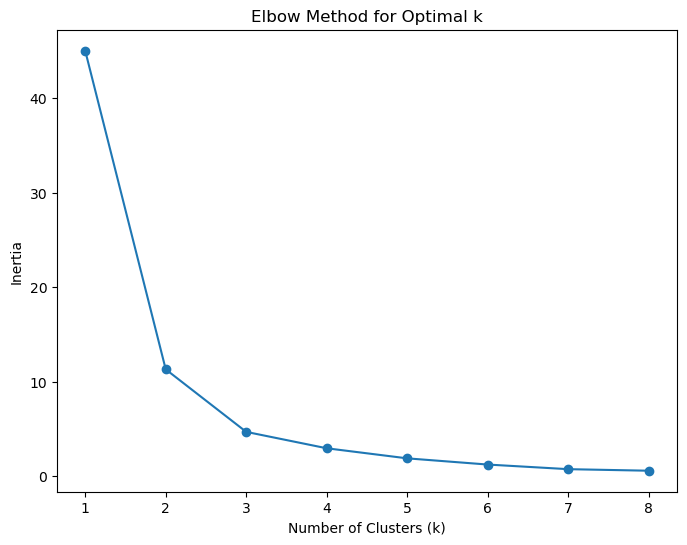

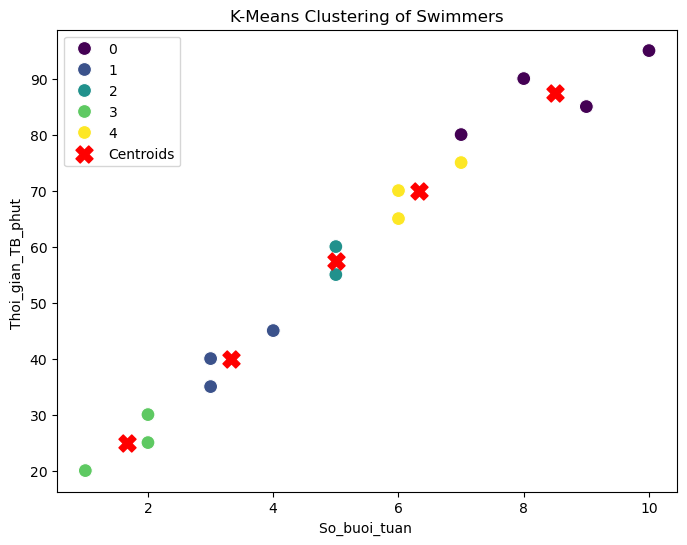

In [6]:
#import standard scaler 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
data_swim = {
    'Ten': ['An', 'Bình', 'Cường', 'Dung', 'Em', 'Phong', 'Giang', 'Hà', 'Khánh', 'Linh', 'Minh', 'Ngọc', 'Phúc', 'Quỳnh', 'Sơn'],
    'So_buoi_tuan': [2, 5, 7, 1, 4, 8, 3, 6, 9, 2, 5, 7, 3, 6, 10],
    'Thoi_gian_TB_phut': [30, 60, 75, 20, 45, 90, 35, 65, 85, 25, 55, 80, 40, 70, 95],
    'So_lop_tuan': [0, 2, 3, 0, 1, 4, 1, 3, 5, 0, 2, 4, 1, 3, 5]
}
data_swim_df = pd.DataFrame(data_swim)
#Tiền xử lý dữ liệu bằng standard scaler
scaler = StandardScaler()
normal_features = data_swim_df[['So_buoi_tuan', 'Thoi_gian_TB_phut', 'So_lop_tuan']]
scaled_features = scaler.fit_transform(normal_features)

#b) Áp dụng phương pháp Elbow
inertia = []
K_range = range(1,9)
for k in K_range: 
    k_means = KMeans(n_clusters = k , random_state = 42)
    k_means.fit(scaled_features)
    inertia.append(k_means.inertia_)
plt.figure(figsize=(8,6))
plt.plot(K_range , inertia, marker = 'o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(K_range)

k_means_optimal = KMeans(n_clusters= 5, random_state = 42)
k_means_optimal.fit(scaled_features)
data_swim_df['Cluster'] = k_means_optimal.labels_
print(data_swim_df)

#Vẽ biểu đồ phân tán với tâm cụm 
plt.figure(figsize=(8,6))
sns.scatterplot(x = normal_features['So_buoi_tuan'], y = normal_features['Thoi_gian_TB_phut'], hue = data_swim_df['Cluster'], palette= 'viridis', s = 100)
centers_origin = scaler.inverse_transform(k_means_optimal.cluster_centers_)
plt.scatter(centers_origin[:,0], centers_origin[:,1], c = 'red', marker = 'X', s = 150, label = 'Centroids')
plt.title('K-Means Clustering of Swimmers')
plt.xlabel('So_buoi_tuan ')
plt.ylabel('Thoi_gian_TB_phut ')
plt.legend()

### Phần 2: Phát hiện Bất thường (1 điểm)
Tạo tập dữ liệu tổng hợp: 500 giao dịch bình thường (trung bình=200, độ lệch chuẩn=50), 15 giao dịch bất thường (trung bình=2000, độ lệch chuẩn=500).
e) Tạo tập dữ liệu, vẽ biểu đồ tần suất (histogram) phân phối giá trị giao dịch.
f) Áp dụng Isolation Forest (contamination=0,03) và One-Class SVM (nu=0,03).
g) Vẽ biểu đồ phân tán so sánh kết quả 2 phương pháp (subplot 1×2).
h) So sánh số điểm bất thường phát hiện bởi mỗi phương pháp. Nhận xét.


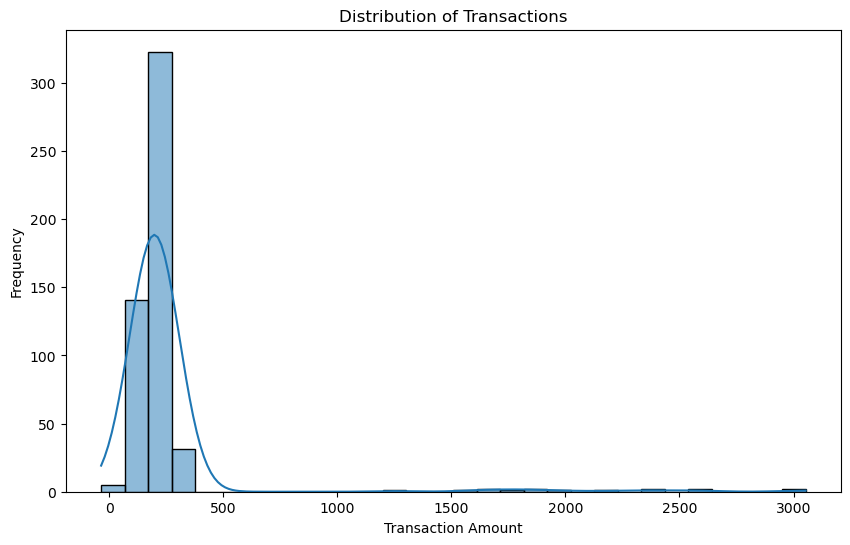

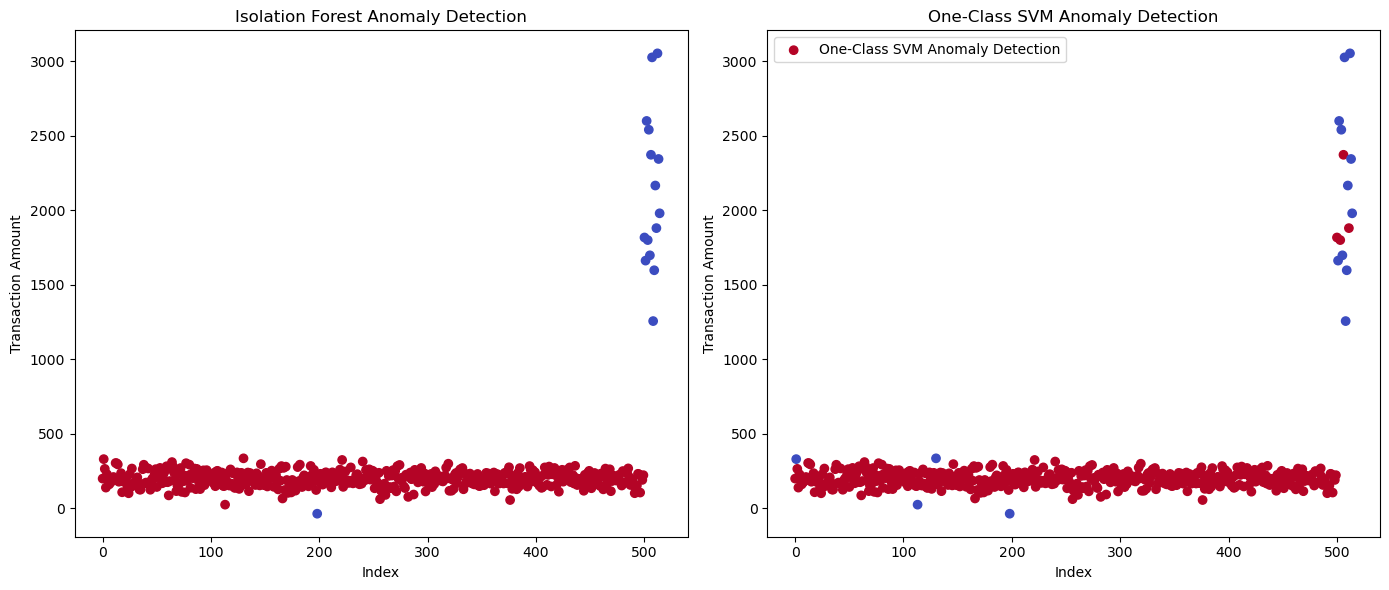

Number of anomalies detected by Isolation Forest: 16
Number of anomalies detected by One-Class SVM: 15


In [7]:
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
# Tạo tập dữ liệu tổng hợp: 500 giao dịch bình thường (trung bình=200, độ lệch chuẩn=50), 15 giao dịch bất thường (trung bình=2000, độ lệch chuẩn=500).
normal_transactions = np.random.normal(loc = 200 , scale = 50 , size = 500)
abnomal_transactions = np.random.normal(loc = 2000, scale = 500 , size = 15)

#e) Tạo tập dữ liệu, vẽ biểu đồ tần suất (histogram) phân phối giá trị giao dịch.
transactions = np.concatenate((normal_transactions, abnomal_transactions))
plt.figure(figsize=(10,6))
sns.histplot(transactions , bins = 30 , kde = True)
plt.title('Distribution of Transactions')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')

#f) Áp dụng Isolation Forest (contamination=0,03) và One-Class SVM (nu=0,03).
iso_forest = IsolationForest(contamination = 0.03 , random_state=42)
new_transactions = transactions.reshape(-1,1)
iso_forest.fit(new_transactions)
iso_labels = iso_forest.predict(new_transactions)
oc_svm = OneClassSVM(nu = 0.03 , kernel = 'rbf', gamma = 'scale')
oc_svm.fit(new_transactions)
oc_svm_labels = oc_svm.predict(new_transactions)

#g) Vẽ biểu đồ phân tán 
fig , axes = plt.subplots(1,2, figsize=(14,6))
axes[0].scatter(range(len(transactions)), transactions, c = iso_labels, cmap = 'coolwarm', marker = 'o', label = 'Isolation Forest Anomaly Detection')
axes[0].set_title('Isolation Forest Anomaly Detection')
axes[0].set_xlabel('Index')
axes[0].set_ylabel('Transaction Amount')
axes[1].scatter(range(len(transactions)), transactions , c = oc_svm_labels, cmap = 'coolwarm', marker = 'o', label = 'One-Class SVM Anomaly Detection')
axes[1].set_title('One-Class SVM Anomaly Detection')
axes[1].set_xlabel('Index')
axes[1].set_ylabel('Transaction Amount')
plt.tight_layout()
plt.legend()
plt.show()

#so sánh các điểm bất thường 
iso_forest_anomalies = np.sum(iso_labels == -1)
oc_svm_anomalies = np.sum(oc_svm_labels == -1)
print(f"Number of anomalies detected by Isolation Forest: {iso_forest_anomalies}")
print(f"Number of anomalies detected by One-Class SVM: {oc_svm_anomalies}")

KẾT QUẢ – Bài C1
Số cụm tối ưu: 3 | Đặc điểm từng cụm: trong lớp học bơi thì số buổi 1 tuần càng cao thì thời gian trung bình trên lớp càng cao , cụm 1 có số buổi thấp nên thời gian trung bình thấp , tương tự với cụm 2 có số buổi cao hơn và cụm 3 có số buổi cao nhất  | Số bất thường IF: 16| Số bất thường SVM: 17
 


Phân tích : 
Với dataset có dữ liệu bất thường rõ ràng và cách biệt lớn so với dữ liệu thông thường thì isolation forest hoạt động tốt hơn với các hoại động nhiều chiều và ít nhạy cảm với outliers . Ngược lại thì one class svm chấp nhận những miscalculations (lower bias ) để đổi lấy độ chính xác cao hơn đối với các dữ liệu lạ (higher variance )

### Bài C2: PCA + t-SNE kết hợp trên Dữ liệu Chữ số (2 điểm)
(Session 8)
Đề bài:
Dùng sklearn.datasets.load_digits() (64 đặc trưng, 10 lớp chữ số viết tay) để thực hiện giảm chiều và trực quan hóa.

Yêu cầu:
a) Tải dữ liệu, chuẩn hóa bằng StandardScaler. Hiển thị kích thước và 10 ảnh mẫu.

b) Chạy PCA giữ 95% phương sai. In số thành phần chính cần thiết. Vẽ biểu đồ scree plot với đường tích lũy.

c) Chạy t-SNE (perplexity=30) trên dữ liệu PCA đã giảm chiều. Vẽ biểu đồ phân tán 2D, tô màu theo lớp (0–9).

d) Chạy t-SNE với 3 giá trị perplexity (5, 15, 30). Vẽ subplot 1×3 so sánh.

e) So sánh thời gian chạy t-SNE trên 64 đặc trưng gốc và trên đặc trưng PCA. Dùng time.time().

f) Nhận xét: áp dụng PCA trước t-SNE có cải thiện chất lượng và tốc độ không?


Original shape of digits data: (1797, 64)
Number of original features : 64
Number of features after PCA: 40
Time taken to run t-SNE on original 64 features : 3.08 seconds
Time taken to run t-SNE on PCA-reduced features : 3.02 seconds


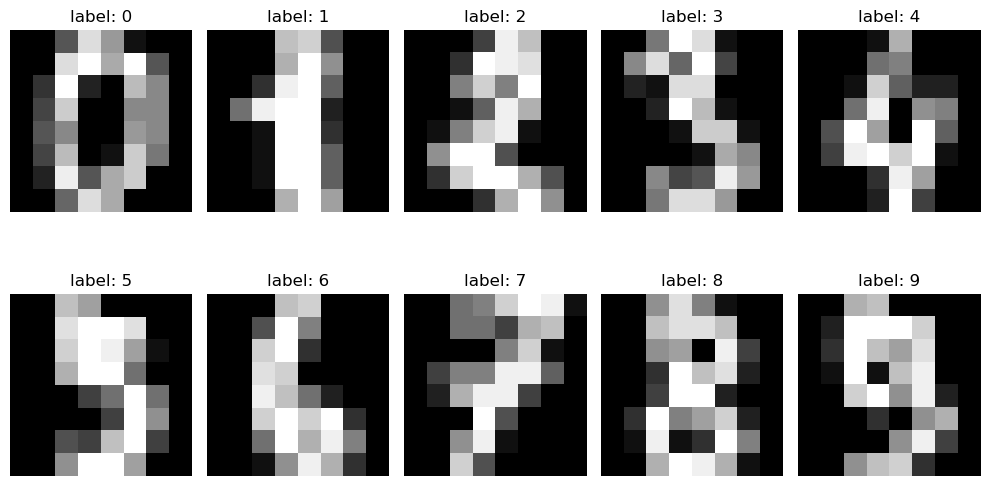

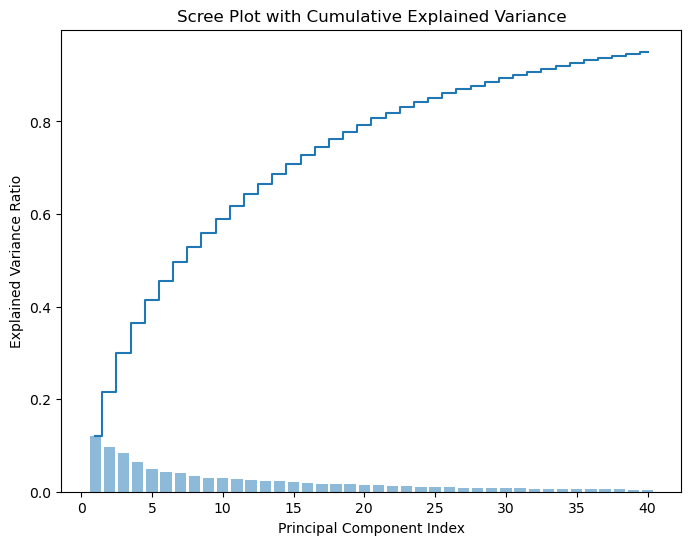

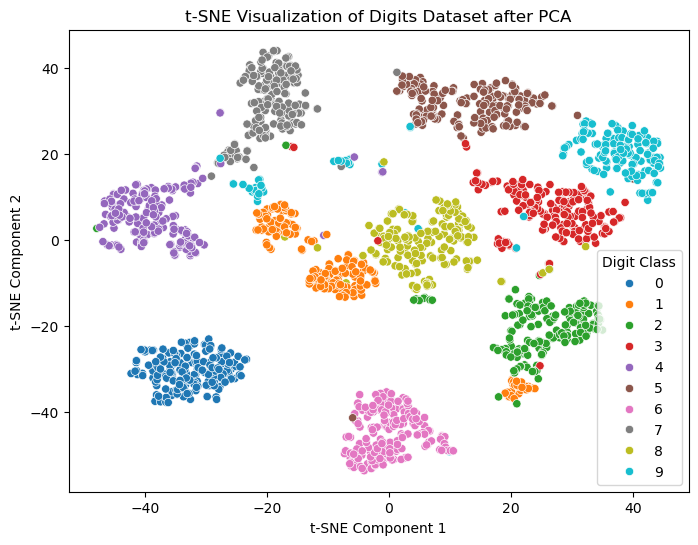

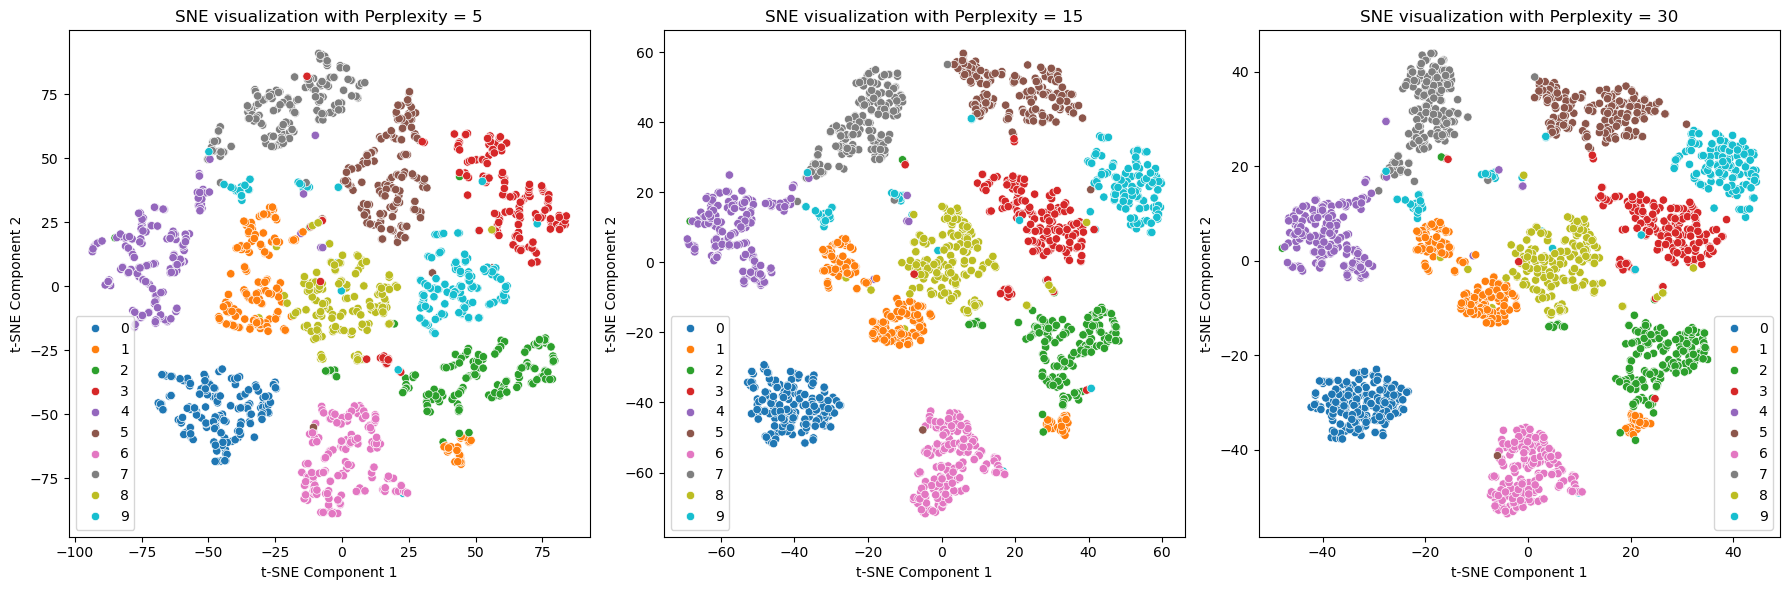

In [ ]:
import time 
from sklearn.datasets import load_digits 
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
digits = load_digits()
X_digits = digits.data 
y_digits = digits.target 

X_digits_scaled = StandardScaler().fit_transform(X_digits)
#hiện thị kích thước và 10  ảnh mẫu 
print(f"Original shape of digits data: {X_digits.shape}")
plt.figure(figsize=(10,6))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_digits[i].reshape(8,8), cmap = 'gray')
    plt.title(f"label: {y_digits[i]}")
    plt.axis('off')
plt.tight_layout()


#Chạy pca giữ 95% phương sai và trực quan hóa kết quả
pca = PCA(n_components= 0.95)
X_pca = pca.fit_transform(X_digits_scaled)
print(f"Number of original features : {X_digits.shape[1]}")
print(f"Number of features after PCA: {X_pca.shape[1]}")
plt.figure(figsize=(8,6))

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha = 0.5, align = 'center', label = 'Individual Explained Variance')
plt.step(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio, where = 'mid', label = 'Cumulative Explained Variance')
plt.xlabel('Principal Component Index')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot with Cumulative Explained Variance')


#So sánh thời gian chạy trên 64 đặc trưng gốc và đặc trưng sau PCA

start_time_original = time.time()
tsne_original = TSNE(n_components = 2 , perplexity= 30 , random_state = 42)
X_tsne_original = tsne_original.fit_transform(X_digits_scaled)
end_time_original = time.time()


#c) Chạy t-SNE trên 40 đặc trưng pca sau khi đã giảm chiều từ 64 xuống
start_time_pca = time.time()
tsne = TSNE(n_components= 2 , perplexity= 30 , random_state = 42)
X_tsne = tsne.fit_transform(X_pca)
end_time_pca = time.time()

print(f"Time taken to run t-SNE on original 64 features : {end_time_original - start_time_original:.2f} seconds")
print(f"Time taken to run t-SNE on PCA-reduced features : {end_time_pca - start_time_pca:.2f} seconds")

plt.figure(figsize=(8,6))
sns.scatterplot(x = X_tsne[:,0], y = X_tsne[:,1], hue = y_digits , palette = 'tab10', legend = 'full')
plt.title('t-SNE Visualization of Digits Dataset after PCA')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(title = 'Digit Class')



# d) Chạy t-SNE với 3 giá trị perplexity (5, 15, 30). Vẽ subplot 1×3 so sánh.
perplexities = [5, 15, 30]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i , perplexity in enumerate(perplexities): 
    tsne = TSNE(n_components = 2 , perplexity = perplexity , random_state = 42)
    X_tsne = tsne.fit_transform(X_pca)
    sns.scatterplot(x = X_tsne[:,0], y = X_tsne[:,1], hue = y_digits , palette = 'tab10', legend = 'full', ax = axes[i])
    axes[i].set_title(f"SNE visualization with Perplexity = {perplexity}")
    axes[i].set_xlabel('t-SNE Component 1')
    axes[i].set_ylabel('t-SNE Component 2')
plt.tight_layout()
plt.show()

### KẾT QUẢ – Bài C2
Số PCs (95% phương sai): 40 | Thời gian t-SNE gốc: 3.08s | Thời gian t-SNE+PCA: 3.02s


### Nhận xét 
Việc giảm chiều dữ liệu với pca(95% phương sai ) => giữ lại 95% dữ liệu quan trọng và bỏ 5% còn lại thường là noise/ nhiễu . Thực hiện phân cụm ở không gian 2 chiều bằng t-sne (perplexity tối ưu là 30 ) bằng dữ liệu gốc chưa pca cho thấy việc chưa loại bỏ nosie => phải tính toán euclidian distance ở 64 chiều ( lúc này khoảng cách sẽ bị kém ý nghĩa hơn ) đồng thời thời gian tính toán cũng lâu hơn . Thực hiện t-sne sau khi đã pca cho thấy tốc độ nhanh hơn ,độ chính xác cao hơn vì đã loại bỏ noise và dc tính toán ở ít chiều hơn => kết quả ổn định hơn vì t-sne ko bị mất ổn định bởi các đặc trưng không quan trọng 

### Bài C3: Luật Kết hợp + Q-Learning (2 điểm)
(Session 9 + Session 10)
Phần 1: FP-Growth cho Gợi ý Sản phẩm (1 điểm)
Cửa hàng thiết bị điện tử ElectroMart – dữ liệu 15 giao dịch:


DataFrame giao dịch:
 Ma_GD                             San_Pham
  1001                 Smart TV, HDMI Cable
  1002           Washing Machine, Detergent
  1003        Bluetooth Speaker, HDMI Cable
  1004               Laptop, Mouse, USB Hub
  1005      Smart TV, Sound Bar, HDMI Cable
  1006            Laptop, Laptop Bag, Mouse
  1007                      Washing Machine
  1008        Smart TV, HDMI Cable, USB Hub
  1009              Laptop, Mouse, Keyboard
  1010         Bluetooth Speaker, Sound Bar
  1011                  Smart TV, Sound Bar
  1012   Laptop, Laptop Bag, Mouse, USB Hub
  1013 Washing Machine, Detergent, Softener
  1014                        Laptop, Mouse
  1015      Smart TV, HDMI Cable, Sound Bar

Ma trận nhị phân:
 Bluetooth Speaker  Detergent  HDMI Cable  Keyboard  Laptop  Laptop Bag  Mouse  Smart TV  Softener  Sound Bar  USB Hub  Washing Machine
             False      False        True     False   False       False  False      True     False      False    False  

C:\Users\Admin\AppData\Local\Temp\ipykernel_27788\2633945540.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = 'lift', y = top_rules['antecedents'].apply(lambda x: ', '.join(list(x))) + ' -> ' + top_rules['consequents'].apply(lambda x: ', '.join(list(x))), data = top_rules, palette = 'viridis')


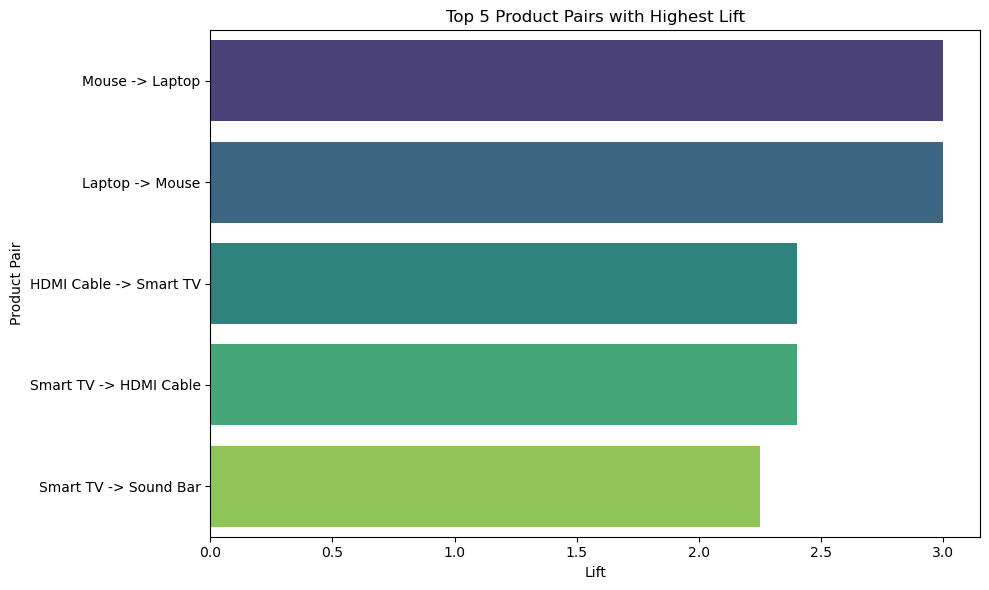

Rule 3: Mouse -> Laptop | Lift : 3.00 | Confidence: 1.00 | Suppport: 0.33
Rule 2: Laptop -> Mouse | Lift : 3.00 | Confidence: 1.00 | Suppport: 0.33
Rule 1: HDMI Cable -> Smart TV | Lift : 2.40 | Confidence: 0.80 | Suppport: 0.27
Rule 0: Smart TV -> HDMI Cable | Lift : 2.40 | Confidence: 0.80 | Suppport: 0.27
Rule 4: Smart TV -> Sound Bar | Lift : 2.25 | Confidence: 0.60 | Suppport: 0.20


In [ ]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

# a) Tạo DataFrame từ 15 giao dịch
transactions = [
    ['Smart TV', 'HDMI Cable'],
    ['Washing Machine', 'Detergent'],
    ['Bluetooth Speaker', 'HDMI Cable'],
    ['Laptop', 'Mouse', 'USB Hub'],
    ['Smart TV', 'Sound Bar', 'HDMI Cable'],
    ['Laptop', 'Laptop Bag', 'Mouse'],
    ['Washing Machine'],
    ['Smart TV', 'HDMI Cable', 'USB Hub'],
    ['Laptop', 'Mouse', 'Keyboard'],
    ['Bluetooth Speaker', 'Sound Bar'],
    ['Smart TV', 'Sound Bar'],
    ['Laptop', 'Laptop Bag', 'Mouse', 'USB Hub'],
    ['Washing Machine', 'Detergent', 'Softener'],
    ['Laptop', 'Mouse'],
    ['Smart TV', 'HDMI Cable', 'Sound Bar'],
]

transaction_df = pd.DataFrame({
    'Ma_GD': range(1001, 1016),
    'San_Pham': [', '.join(t) for t in transactions]
})
print("DataFrame giao dịch:")
print(transaction_df.to_string(index=False)) 

# Mã hóa thành ma trận nhị phân
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
te_df = pd.DataFrame(te_array, columns = te.columns_)
print("\nMa trận nhị phân:")
print(te_df.to_string(index = False))

# Chạy FP-Growth 
frequent_itemsets = fpgrowth(te_df , min_support = 0.2 , use_colnames= True)
rules = association_rules(frequent_itemsets, metric = 'confidence', min_threshold= 0.5)
# Vẽ biểu đồ thanh (bar chart) top 5 cặp sản phẩm có lift cao nhất.
top_rules = rules.sort_values(by = 'lift', ascending = False).head(5)
plt.figure(figsize=(10,6))
sns.barplot(x = 'lift', y = top_rules['antecedents'].apply(lambda x: ', '.join(list(x))) + ' -> ' + top_rules['consequents'].apply(lambda x: ', '.join(list(x))), data = top_rules, palette = 'viridis')
plt.title('Top 5 Product Pairs with Highest Lift')
plt.xlabel('Lift')
plt.ylabel('Product Pair')
plt.tight_layout()
plt.show()

#In ra số lần xuất hiện của top 5 sản phẩm trong tập giao dịch và confidence của các quy tắc liên quan đến sản phẩm đó.
for index , row in top_rules.iterrows():
    antecedents = row['antecedents']
    consequents = row['consequents']
    lift = row['lift']
    confidence = row['confidence']
    support = row['support']
    print(f"Rule {index}: {','.join(antecedents)} -> {','.join(consequents)} | Lift : {lift:.2f} | Confidence: {confidence:.2f} | Suppport: {support:.2f}")

### Phần 2: Q-Learning cho Mê cung 3×3 (1 điểm)

Thiết kế môi trường lưới (Grid World) 3×3: S(Xuất phát) | E(Trống) | P(Bẫy, −5) / E(Trống) | W(Tường) | E(Trống) / P(Bẫy, −5) | E(Trống) | G(Đích, +20).

Quy tắc: Không đi vào ô Tường; Bẫy = −5 (kết thúc); Đích = +20 (kết thúc); Mỗi bước = −0,1.

e) Xây dựng lớp (class) Maze3x3 mô phỏng môi trường.

f) Huấn luyện tác tử Q-Learning với 2000 episode (α=0,1, γ=0,9, ε-greedy suy giảm).

g) Vẽ bản đồ nhiệt (heatmap) giá trị Q và hiển thị chính sách tối ưu (mũi tên chỉ hướng).

h) Vẽ biểu đồ phần thưởng qua các episode. Nhận xét tốc độ hội tụ.


Huận luyện xong sau 2000 episode.


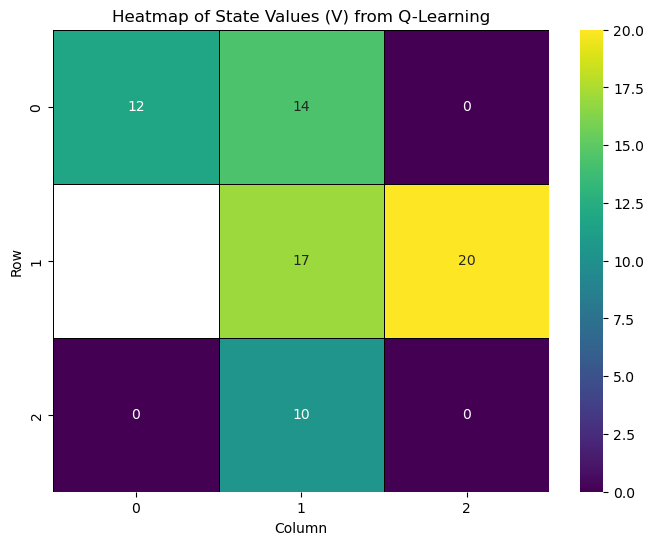

Chính sách tối ưu cho mỗi trạng thái:
    →          ↓          ↑      

   Wall        →          ↓      

    ↑          →          ↑      



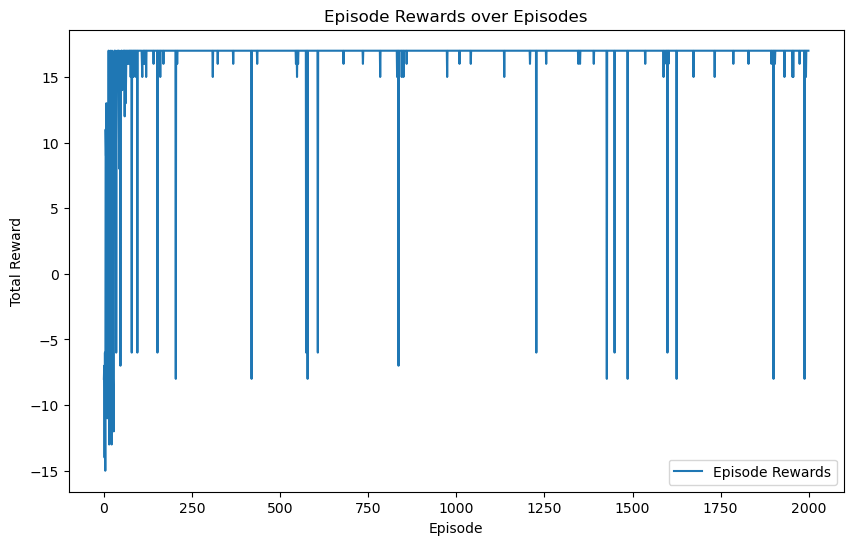

In [1]:

import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

# Thiết kế môi trường lưới (Grid World) 3×3: S(Xuất phát) | E(Trống) | P(Bẫy, −5) / E(Trống) | W(Tường) | E(Trống) / P(Bẫy, −5) | E(Trống) | G(Đích, +20).
class Maze3x3:
    def __init__(self): 
        self.rows = 3
        self.cols = 3

        self.start = (0,0)
        self.goal = (2,2)
        self.traps = [(0,2), (2,0)]
        self.walls = [(1,0)]

        self.actions = [0,1,2,3] # 0: up , 1: down , 2: left , 3: right
        self.actions_names = ['↑', '↓', '←', '→']
        self.actions_effects = {
            0: (-1,0),
            1: (1,0), 
            2: (0,-1),
            3: (0,1)
        }
        self.state = self.start 

    def reset(self):
        self.state = self.start
        return self.state
    
    def step(self, action):
        row , col = self.state
        delta_row , delta_col = self.actions_effects[action]
        new_row = row + delta_row 
        new_col = col + delta_col

        if (new_row < 0 or new_row >= self.rows or new_col < 0 or new_col >= self.cols or (new_row, new_col) in self.walls):
            return self.state , -1 , False
        
        self.state = (new_row , new_col)

        if self.state in self.traps: 
            return self.state , -5 , True
        elif self.state == self.goal: 
            return self.state, 20 , True 
        else: 
            return self.state , -1 , False
        
    def get_valid_states(self): 
        valid_states = []
        for c in range(self.cols):
            for r in range(self.rows): 
                if (r,c) not in self.walls:
                    valid_states.append((r,c))
        return valid_states


#) Huấn luyện tác tử Q-Learning với 2000 episode (α=0,1, γ=0,9, ε-greedy suy giảm).

#parameters
alpha = 0.1
ganma = 0.9 
epsilon_start = 1.0
epsilon_end = 0.01
epsilon_decay = 0.03
num_episodes = 2000
max_steps = 100

env = Maze3x3() #Khởi tạo môi trường
Q = {} 
for r in range(env.rows):  #Khởi tạo Bảng q ban đầu với mọi giá trị = 0 
    for c in range(env.cols): 
        if (r,c) not in env.walls:
            for a in env.actions:
                Q[(r,c), a] = 0.0
#khởi tạo episode reward 
episode_rewards = []

for episode in range(num_episodes):
    state = env.reset()
    total_reward = 0
    #Cập nhật epsilon theo từng episode
    epsilon = epsilon_end + (epsilon_start - epsilon_end) * np.exp(-epsilon_decay * episode)

    for step in range(max_steps):
        #chọn actions theo epsilon-greedy
        if random.uniform(0,1) < epsilon: 
            action = random.choice(env.actions)
        else: 
            #chọn action có q-value cao nhất 
            q_values = [Q.get((state,a),0.0) for a in env.actions]
            max_q = max(q_values)
            #Nếu có nhiều action có cùng q-value cao nhất, chọn ngẫu nhiên trong số đó
            best_actions = [a for a , q in zip(env.actions , q_values) if q == max_q]
            action = random.choice(best_actions)

        #thực hiện action và quan sát reward và trạng thái mới
        new_state , reward , done = env.step(action)
        #cập nhật reward 
        total_reward += reward
        #Cập nhật q-value theo công thức Q-learning
        old_q_value = Q.get((state, action), 0.0)

        if done: 
            next_max_q = 0.0
        else: 
            next_max_q = max([Q.get((new_state, a), 0.0) for a in env.actions])

        new_q_value = old_q_value + alpha * (reward + ganma * next_max_q - old_q_value)
        #Cập nhật state và q-value
        Q[(state, action)] = new_q_value
        
        if done: 
            break
        state = new_state
        
    episode_rewards.append(total_reward)

print(f"Huận luyện xong sau {num_episodes} episode.")
# #In ra bảng Q-Table cuối cùng 3x3 định dạng đẹp sau khi huấn luyện
# print("\nBảng Q-Table sau khi huấn luyện:")
# # for r in range(env.rows): 
# #     for c in range(env.cols): 
# #         if (r,c) in env.walls: 
# #             print("Wall".center(15), end = " ")
# #         else:
# #             q_values = [Q.get(((r,c), a), 0.0) for a in env.actions]
# #             q_values_str = ', '.join([f"{env.actions_names[a]} : {q:.2f}" for a , q in zip(env.actions , q_values)])
# #             print(q_values_str.center(15), end = " ")
# #     print("\n")


#Trực quan hóa heatmap của q table và chính sách tối ưu cho mỗi trạng thái (chọn action có q-value cao nhất) trên lưới 3x3. Tường được đánh dấu là NaN để không hiển thị trên heatmap.
V = np.zeros((env.rows, env.cols))

policy = {} #Chính sách tốt nhất cho mỗi trạng thái

for r in range(env.rows):
    for c in range(env.cols):
        if (r,c) in env.walls:
            V[r,c] = np.nan  # Đánh dấu tường là NaN để không hiển thị trên heatmap
        else:
            q_values = [Q.get(((r,c), a), 0.0) for a in env.actions]
            V[r,c] = max(q_values)
            best_action = env.actions[np.argmax(q_values)]
            policy[(r,c)] = best_action

plt.figure(figsize=(8,6))
sns.heatmap(V , annot = True , cmap = 'viridis', cbar = True , linewidths= 0.5 , linecolor = 'black')
plt.title('Heatmap of State Values (V) from Q-Learning')
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()

#In ra chính sách tối ưu cho mỗi trạng thái (chọn action có q-value cao nhất) trên lưới 3x3. Tường được đánh dấu là NaN để không hiển thị trên heatmap.
policy_grid = np.full((env.rows, env.cols), '', dtype = object)

for r in range(env.rows):
    for c in range(env.cols): 
        if(r,c) in env.walls:
            policy_grid[r,c] = 'Wall'
        else:
            best_action = policy.get((r,c), None)
            if best_action is not None: 
                policy_grid[r,c] = env.actions_names[best_action]


print("Chính sách tối ưu cho mỗi trạng thái:")

for r in range(env.rows):
    for c in range(env.cols):
        print(policy_grid[r,c].center(10), end = " ")
    print("\n")


# Vẽ biểu đồ phần thưởng qua các episode. Nhận xét tốc độ hội tụ.
plt.figure(figsize=(10,6))
plt.plot(episode_rewards, label = 'Episode Rewards')
plt.title('Episode Rewards over Episodes')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.legend()
plt.show()


KẾT QUẢ – Bài C3
FP-Growth: Top 5 lift = 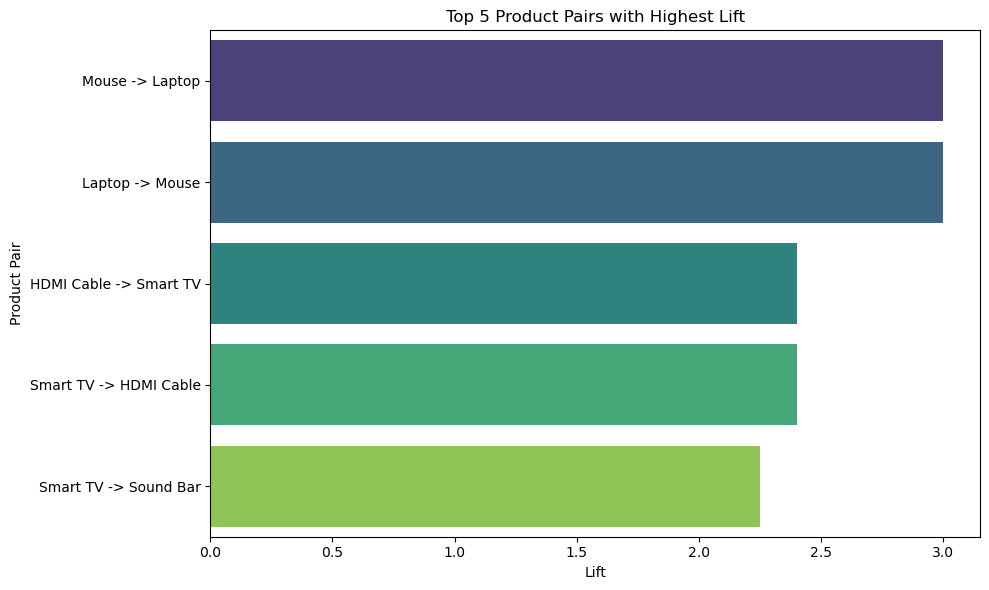

 | Đề xuất combo: Combo sản phẩm mouse -> laptop và laptop -> mouse trả về kết quả người mua 1 sản phẩm chắc chắn sẽ mua sản phẩm còn lại , vì vậy trong cửa hàng hãy bố trí các sản phẩm gần nhau , kèm theo ưu đãi hấp dẫn để đảm bảo lift không giảm dần vì bị ảnh hưởng bởi yếu tố mùa vụ  |
 
  Q-Learning: Chính sách tối ưu = Trong ma trận 3x3 , nếu xét start là vị trí (0, 0) và đích là vị trí (2,2) thì chính sách tối ưu đến đích dựa trên q-value cao nhất tại mỗi state : 
  Chính sách tối ưu cho mỗi trạng thái:
  $$
\begin{bmatrix}
\rightarrow & \downarrow & \uparrow \\
\text{Wall} & \rightarrow & \downarrow \\
\uparrow & \rightarrow & \uparrow
\end{bmatrix}
$$
 


Nhận xét : 

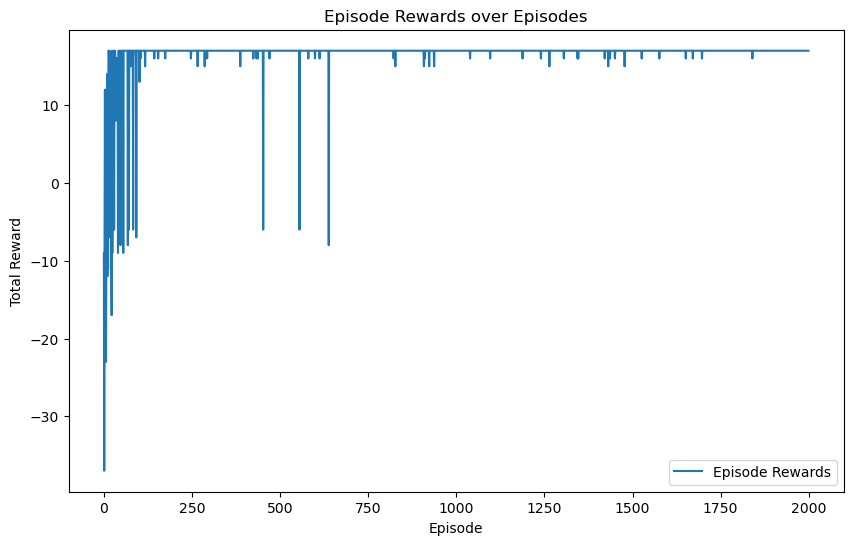

 Biểu đồ cho thấy qua các episode hay lần lặp thì tổng reward tăng dần , biểu thị cho việc episilon hay sự khám phá ngẫu nhiên đã giảm xuống và đã bắt đầu khám phá theo trạng thái q-value cao nhất của mỗi state . Biểu thị cho sự hội tụ của q-value vào trong q-table là khi sự biến động của reward không còn cao (chọn action dựa trên q-value cao nhất chứ không còn mang tính ngẫu nhiên như epsilon) và reward càng ngày tăng lên sau các episodes

Bài D1: Học sâu – ANN dự đoán giá nhà + CNN phân loại Fashion-MNIST (2 điểm)
(Session 11 + Session 12)


Phần 1: Mạng nơ-ron nhân tạo (ANN) dự đoán giá nhà (1 điểm)


Tạo tập dữ liệu tổng hợp 200 mẫu nhà ở với các đặc trưng: diện tích, số phòng ngủ, số 
phòng tắm, số tầng, mặt đường chính (Yes/No), điều hòa (Yes/No), giá (target).


a) Tạo dữ liệu bằng np.random.seed(42). Mã hóa các đặc trưng phân loại.


b) Xây dựng ANN: 3 tầng ẩn (64 → 32 → 16), đầu ra Dense(1). Biên dịch với loss='mse', optimizer='adam'. Huấn luyện với EarlyStopping.


c) Vẽ biểu đồ đường cong mất mát huấn luyện/kiểm định (training/validation loss curves).


d) Tính MAE, RMSE, R² trên tập kiểm tra. Vẽ biểu đồ phân tán giá trị thực tế và dự đoán.




c:\Users\Admin\anaconda3\envs\session1_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


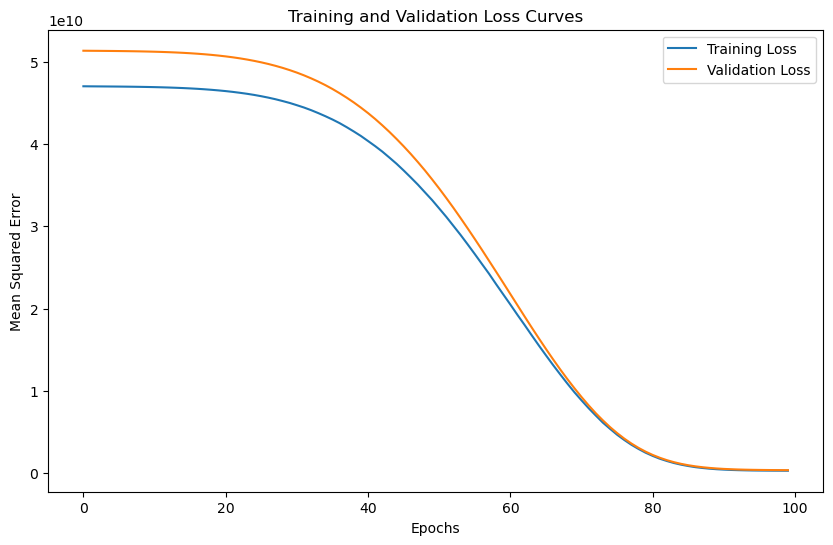

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Mean Absolute Error (MAE): 15787.71
Root Mean Squared Error (RMSE): 19850.44
R² Score: 0.9233


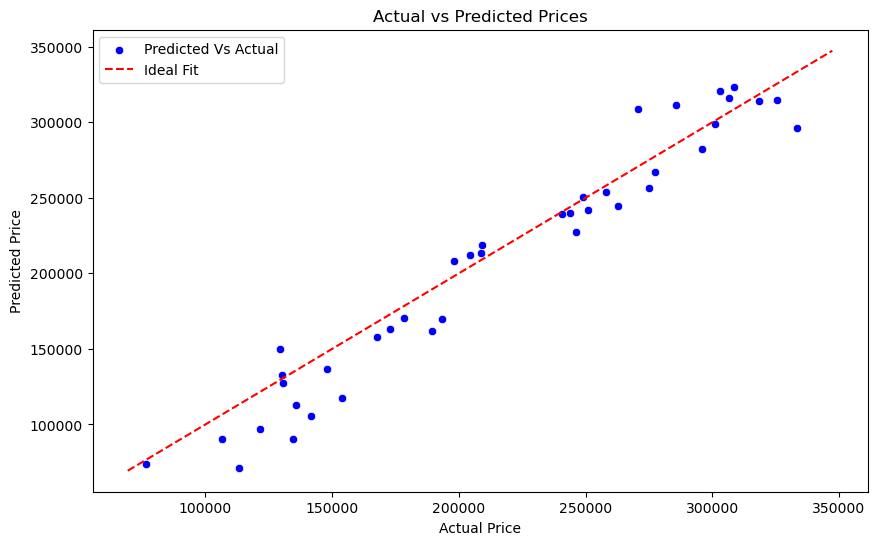

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt


np.random.seed(42)
num_samples = 200
area = np.random.uniform(50, 300 , num_samples)
bedrooms = np.random.randint(1,6,num_samples)
bathrooms = np.random.randint(1,4,num_samples)
floors = np.random.randint(1,4,num_samples)
main_road = np.random.choice(['Yes', 'No'], num_samples)
air_conditioning = np.random.choice(['Yes', 'No'], num_samples)


#Giá nhà được tạo dựa trên một hàm giả định với một số yếu tố ngẫu nhiên
price = (area * 1000) + (bedrooms * 5000) + (bathrooms * 3000) + (floors * 2000) + (main_road == 'Yes') * 10000 + (air_conditioning == 'Yes') * 8000 + np.random.normal(0,10000, num_samples)


#Tạo DataFrame
data_houses_df = pd.DataFrame({
    'Area': area,
    'Bedrooms': bedrooms,
    'Bathrooms': bathrooms,
    'Floors': floors,
    'Main_Road': main_road,
    'Air_Conditioning': air_conditioning,
    'Price': price
})


data_houses_df['Main_Road'] = data_houses_df['Main_Road'].map({'Yes': 1 , 'No': 0})
data_houses_df['Air_Conditioning'] = data_houses_df['Air_Conditioning'].map({'Yes': 1 , 'No': 0})



X = data_houses_df.drop('Price', axis = 1).values
y = data_houses_df['Price'].values

# Xây dựng mô hình ANN
model = Sequential([
    Dense(64 , activation = 'relu', input_shape = (X.shape[1], )),
    Dense(32 , activation = 'relu'),
    Dense(16 , activation = 'relu'),
    Dense(1)
])
model.compile(optimizer = 'adam', loss = 'mse')
early_stopping = EarlyStopping(monitor = 'val_loss', patience = 10 , restore_best_weights = True)
history = model.fit(X, y, validation_split = 0.2 , epochs = 100 , callbacks = [early_stopping], verbose = 0)


plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.title('Training and Validation Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.show()


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Dự đoán trên tập kiểm tra

X_test = X[int(0.8 * len(X)):]
y_test = y[int(0.8 * len(y)):]
y_pred = model.predict(X_test).flatten()



mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

# Vẽ biểu đồ phân tán giá trị thực tế và dự đoán
plt.figure(figsize=(10,6))
sns.scatterplot(x = y_test , y = y_pred , color = 'blue', label = 'Predicted Vs Actual')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label = 'Ideal Fit')
plt.title('Actual vs Predicted Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.show()

ANN model metrics score : 


Mean Absolute Error (MAE): 15787.71


Root Mean Squared Error (RMSE): 19850.44


R² Score: 0.9233

Phần 2: Mạng tích chập (CNN) phân loại Fashion-MNIST (1 điểm)


Fashion-MNIST: ảnh xám 28×28 pixel, 10 lớp quần áo.


e) Nạp tập dữ liệu fashion_mnist. Hiển thị 10 ảnh mẫu với tên lớp.


f) Xây dựng CNN: Conv2D(32) → MaxPool → Conv2D(64) → MaxPool → Conv2D(128) → Flatten → Dense(128) → Dropout(0,5) → Dense(10, softmax). Huấn luyện 15 epoch.


g) Đánh giá: độ chính xác trên tập kiểm tra, bản đồ nhiệt ma trận nhầm lẫn (confusion matrix).


h) So sánh: thay các tầng tích chập bằng tầng kết nối đầy đủ (ANN thuần). Độ chính xác khác bao nhiêu?

Epoch 1/15


c:\Users\Admin\anaconda3\envs\session1_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7727 - loss: 0.6218 - val_accuracy: 0.8552 - val_loss: 0.3810
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8635 - loss: 0.3843 - val_accuracy: 0.8803 - val_loss: 0.3189
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8840 - loss: 0.3256 - val_accuracy: 0.8926 - val_loss: 0.2920
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8964 - loss: 0.2883 - val_accuracy: 0.8949 - val_loss: 0.2835
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9033 - loss: 0.2650 - val_accuracy: 0.9029 - val_loss: 0.2611
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9131 - loss: 0.2425 - val_accuracy: 0.9079 - val_loss: 0.2547
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9198 - loss: 0.2214 - val_accuracy: 0.9072 - val_loss: 0.2524
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9248 - loss: 0.2034 - val_accurac

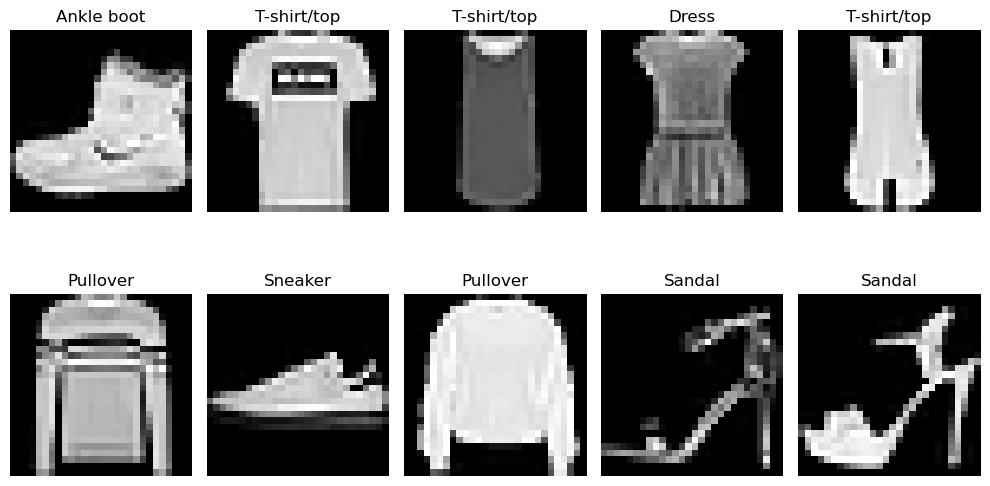

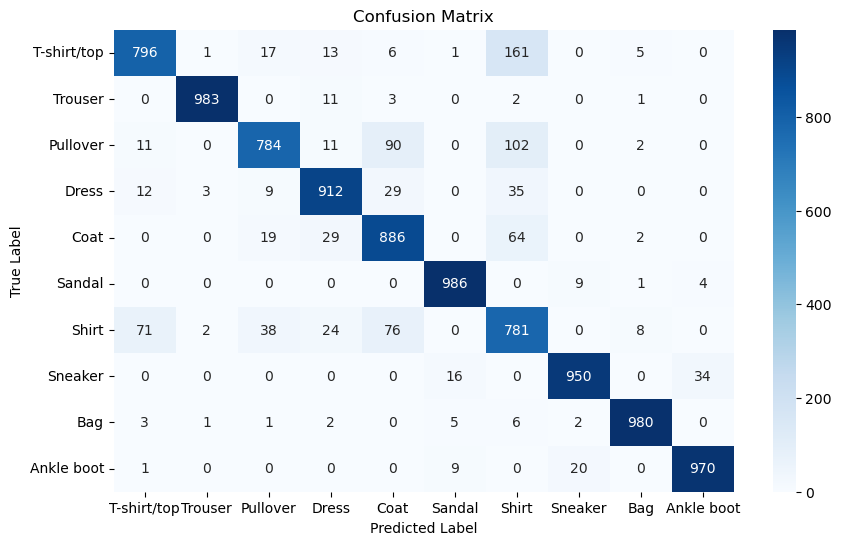

Epoch 1/15


c:\Users\Admin\anaconda3\envs\session1_env\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7102 - loss: 0.7910 - val_accuracy: 0.8303 - val_loss: 0.4603
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8009 - loss: 0.5670 - val_accuracy: 0.8363 - val_loss: 0.4356
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8190 - loss: 0.5176 - val_accuracy: 0.8531 - val_loss: 0.3977
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8294 - loss: 0.4904 - val_accuracy: 0.8544 - val_loss: 0.4120
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8340 - loss: 0.4765 - val_accuracy: 0.8398 - val_loss: 0.4188
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8391 - loss: 0.4603 - val_accuracy: 0.8644 - val_loss: 0.3737
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8414 - loss: 0.4465 - val_accuracy: 0.8611 - val_loss: 0.3768
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8440 - loss: 0.4466 - val_accurac

In [ ]:
#e) Nạp tập dữ liệu fashion_mnist. Hiển thị 10 ảnh mẫu với tên lớp.
from tensorflow.keras.datasets import fashion_mnist
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D , Flatten , Dense , Dropout
from tensorflow.keras.utils import to_categorical 


(X_train_fashion , y_train_fashion), (X_test_fashion , y_test_fashion) = fashion_mnist.load_data()
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


plt.figure(figsize=(10,6))
for i in range(10): 
    plt.subplot(2, 5 , i+1)
    plt.imshow(X_train_fashion[i], cmap = 'gray')
    plt.title(class_names[y_train_fashion[i]])
    plt.axis('off')
plt.tight_layout()


X_train_fashion = X_train_fashion.reshape(-1,28,28,1).astype('float32') / 255.0
X_test_fashion = X_test_fashion.reshape(-1,28,28,1).astype('float32') / 255.0
y_train_fashion_categorical = to_categorical(y_train_fashion, num_classes = 10)
y_test_fashion_categorical = to_categorical(y_test_fashion, num_classes = 10)

#Xây dựng model CNN đơn giản 
model_cnn = Sequential([
    Conv2D(32, (3,3), activation = 'relu', input_shape = (28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation = 'relu'),
    MaxPooling2D((2,2)),
    Conv2D(128, (3,3), activation = 'relu'),
    Flatten(),
    Dense(128, activation = 'relu'),
    Dropout(0.5),
    Dense(10, activation = 'softmax')

])
model_cnn.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
history_cnn = model_cnn.fit(X_train_fashion , y_train_fashion_categorical, validation_split = 0.2 , epochs = 15 , verbose = 1)

#bản đồ nhiệt ma trận nhầm lẫn (confusion matrix).
test_loss, test_accuracy = model_cnn.evaluate(X_test_fashion , y_test_fashion_categorical , verbose = 0)
print(f"Test Accuracy: {test_accuracy:.4f}")

y_pred_fashion = model_cnn.predict(X_test_fashion)
y_pred_classes = np.argmax(y_pred_fashion, axis = 1)

cm = confusion_matrix(y_test_fashion, y_pred_classes)
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', xticklabels = class_names, yticklabels = class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#h) So sánh: thay các tầng tích chập bằng tầng kết nối đầy đủ (ANN thuần). Độ chính xác khác bao nhiêu?
model_ann = Sequential([
    Flatten(input_shape = (28,28,1)),
    Dense(512, activation = 'relu'),
    Dropout(0.5),
    Dense(256, activation = 'relu'),
    Dropout(0.5),
    Dense(128, activation = 'relu'),
    Dropout(0.5),
    Dense(10, activation = 'softmax')
])
model_ann.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
history_ann = model_ann.fit(X_train_fashion , y_train_fashion_categorical, validation_split = 0.2 , epochs = 15 , verbose = 1)
test_loss_ann, test_accuracy_ann = model_ann.evaluate(X_test_fashion , y_test_fashion_categorical , verbose = 0)
print(f"Test Accuracy of ANN: {test_accuracy_ann:.4f}")
print(f"Test Accuracy of CNN: {test_accuracy:.4f}")
print(f"Difference in Accuracy in percentage (CNN - ANN): {test_accuracy - test_accuracy_ann :.4f}")



CNN Accuracy= 90.28 % 


| ANN thuần Accuracy= 86.94 % |


 Chênh lệch= 3.34%

# Nhận Xét 
#### CNN thường có hiệu suất tốt hơn ANN thuần khi làm việc với dữ liệu hình ảnh vì khả năng tự động trích xuất đặc trưng từ dữ liệu. CNN có thể học được các đặc trưng không gian và cấu trúc của hình ảnh thông qua các tầng tích chập, trong khi ANN thuần phải dựa vào việc làm phẳng dữ liệu và có thể bỏ lỡ các đặc trưng quan trọng. Do đó, sự khác biệt về độ chính xác giữa CNN và ANN thuần thường là đáng kể, với CNN thường đạt được độ chính xác cao hơn trên các tác vụ liên quan đến hình ảnh.